# Load Libraries and Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anasmohammedtahir/covidqu")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'covidqu' dataset.
Path to dataset files: /kaggle/input/covidqu


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [ ]:
path = "/kaggle/input/covidqu/Infection Segmentation Data/Infection Segmentation Data"

train_path = os.path.join(path, "Train")
test_path  = os.path.join(path, "Test")

In [ ]:
def load_dataset(split_path):
    X, Y = [], []

    for cls in ["COVID-19", "Non-COVID", "Normal"]:
        img_dir = os.path.join(split_path, cls, "images")
        msk_dir = os.path.join(split_path, cls, "infection masks")

        for name in os.listdir(img_dir):
            img = cv2.imread(os.path.join(img_dir, name), 0) / 255.0
            mask = cv2.imread(os.path.join(msk_dir, name), 0)
            mask = (mask > 0).astype("float32")

            X.append(img[..., None])
            Y.append(mask[..., None])

    return np.array(X), np.array(Y)

In [ ]:
X_train, Y_train = load_dataset(train_path)
X_test,  Y_test  = load_dataset(test_path)

# U-Net Model

In [ ]:
def UNet(input_shape=(256,256,1)):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D()(c3)

    # Bottleneck
    b = Conv2D(512, 3, activation='relu', padding='same')(p3)
    b = Conv2D(512, 3, activation='relu', padding='same')(b)

    # Decoder
    u3 = UpSampling2D()(b)
    u3 = Concatenate()([u3, c3])
    c4 = Conv2D(256, 3, activation='relu', padding='same')(u3)
    c4 = Conv2D(256, 3, activation='relu', padding='same')(c4)

    u2 = UpSampling2D()(c4)
    u2 = Concatenate()([u2, c2])
    c5 = Conv2D(128, 3, activation='relu', padding='same')(u2)
    c5 = Conv2D(128, 3, activation='relu', padding='same')(c5)

    u1 = UpSampling2D()(c5)
    u1 = Concatenate()([u1, c1])
    c6 = Conv2D(64, 3, activation='relu', padding='same')(u1)
    c6 = Conv2D(64, 3, activation='relu', padding='same')(c6)

    outputs = Conv2D(1, 1, activation='sigmoid')(c6)

    return Model(inputs, outputs)


In [ ]:
model = UNet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=8,
    verbose=1
)

Epoch 1/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 203s 349ms/step - accuracy: 0.9306 - loss: 0.2770
Epoch 2/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 175s 376ms/step - accuracy: 0.9312 - loss: 0.2053
Epoch 3/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 179s 383ms/step - accuracy: 0.9328 - loss: 0.1836
Epoch 4/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 179s 384ms/step - accuracy: 0.9307 - loss: 0.1657
Epoch 5/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 178s 383ms/step - accuracy: 0.9337 - loss: 0.1505
Epoch 6/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 178s 382ms/step - accuracy: 0.9374 - loss: 0.1434
Epoch 7/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 179s 384ms/step - accuracy: 0.9429 - loss: 0.1313
Epoch 8/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 179s 384ms/step - accuracy: 0.9448 - loss: 0.1240
Epoch 9/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 179s 383ms/step - accuracy: 0.9507 - loss: 0.1113
Epoch 10/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 202s 383ms/step - accuracy: 0.9533 - loss: 0.1059
Epoch 11/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 178s 383ms/step - accuracy: 0.9553 - loss: 0.1023
Epoch 12

# Evaluation

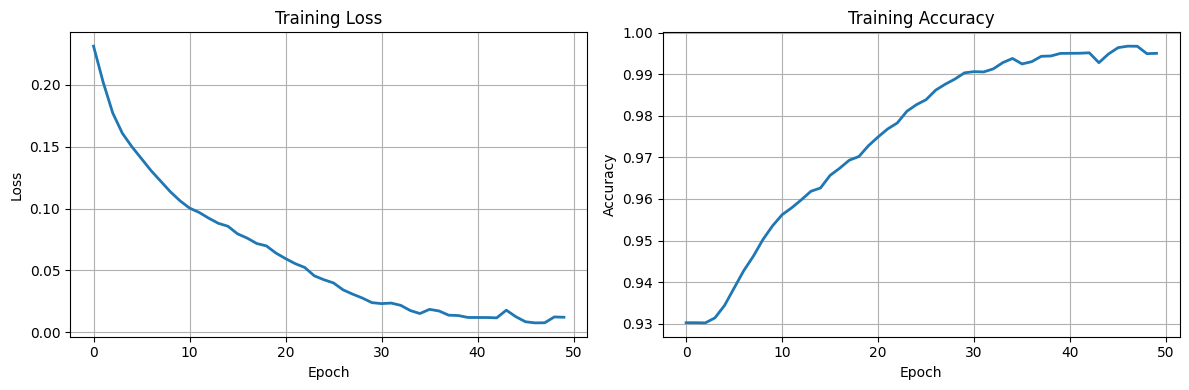

In [ ]:
plt.figure(figsize=(12,4))
# Loss curve
plt.subplot(1,2,1)
plt.plot(history.history['loss'], linewidth=2)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(12,4))
# Accuracy curve
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], linewidth=2)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [ ]:
preds = model.predict(X_test)
def visualize_result(X, Y, preds, idx):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Input Image")
    plt.imshow(X[idx].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(Y[idx].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(preds[idx].squeeze() > 0.5, cmap='gray')
    plt.axis('off')

    plt.show()

37/37 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step


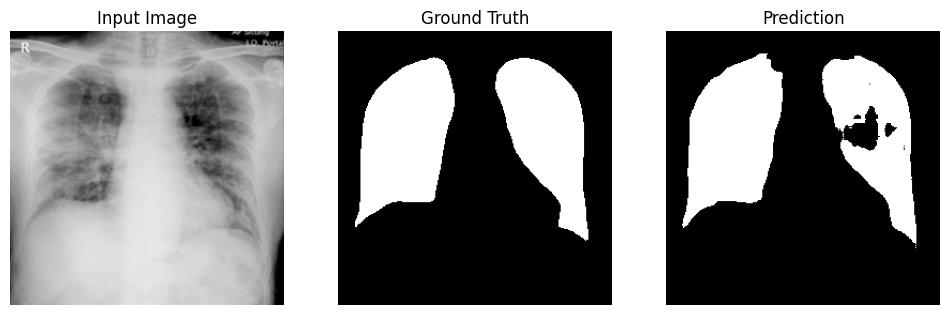

In [ ]:
visualize_result(X_test, Y_test, preds, idx=0)

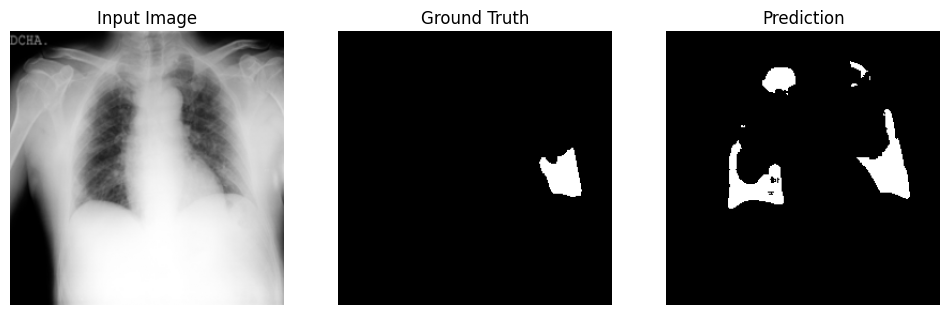

In [ ]:
visualize_result(X_test, Y_test, preds, idx=10)

In [ ]:
def dice_coef(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    intersection = np.sum(y_true * y_pred)
    denom = np.sum(y_true) + np.sum(y_pred)
    return 0.0 if denom == 0 else 2 * intersection / denom

In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    inter = np.sum(y_true * y_pred)
    return (2*inter + smooth) / (np.sum(y_true)+np.sum(y_pred)+smooth)

In [ ]:
dice_scores = []

for i in range(len(X_test)):
    dice_scores.append(
        dice_coef(Y_test[i], preds[i])
    )

mean_dice = np.mean(dice_scores)

plt.figure(figsize=(6,4))
plt.hist(dice_scores, bins=20)

plt.axvline(
    mean_dice,
    linestyle='--',
    linewidth=2,
    label=f"Mean Dice = {mean_dice:.3f}"
)

plt.title("Dice Score Distribution on Test Set")
plt.xlabel("Dice Score")
plt.ylabel("Number of Images")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'dice_coef' is not defined

In [ ]:
dice_nonzero = []

for i in range(len(X_test)):
    if Y_test[i].sum() > 0:
        dice = dice_coef(Y_test[i], preds[i])
        if dice > 0:
            dice_nonzero.append(dice)

dice_nonzero = np.array(dice_nonzero)
median_dice = np.median(dice_nonzero)

plt.figure(figsize=(6,4))
plt.hist(dice_nonzero, bins=20)

plt.axvline(
    median_dice,
    linestyle='--',
    linewidth=2,
    label=f"Median Dice (non-zero) = {median_dice:.3f}"
)

plt.title("Dice Score Distribution (Images with Infection)")
plt.xlabel("Dice Score")
plt.ylabel("Number of Images")
plt.legend()
plt.grid(True)
plt.show()